# Modern Portfolio Theory: Efficient Frontier & Out-of-Sample Backtest

**Research question:** What does the Markowitz efficient frontier look like
for a real 20-stock universe, and how does the resulting max-Sharpe
portfolio perform on data the optimizer never saw?

All data is real historical price data from Yahoo Finance (`yfinance`).
See `README.md` for methodology and limitations before drawing conclusions.


## 1. Setup

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TRAIN_START, TRAIN_END = "2018-01-01", "2022-12-31"
TEST_START, TEST_END   = "2023-01-01", None  # None = through the most recent available date

RISK_FREE_RATE = 0.045  # annualized proxy (e.g. current ~13-week T-bill yield) -- update as needed


## 2. Load ticker universe and download price data

In [5]:
# 2. Load ticker universe and download price data

tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "JPM", "V", "MA", "JNJ",
    "WMT", "PG", "KO", "PEP", "XOM",
    "CVX", "HD", "DIS", "NFLX", "COST"
]

benchmark = "^GSPC"

all_symbols = tickers + [benchmark]

raw = yf.download(
    all_symbols,
    start=TRAIN_START,
    auto_adjust=True,
    progress=False
)["Close"]

# Remove columns with no data
raw = raw.dropna(axis=1, how="all")

missing = [t for t in all_symbols if t not in raw.columns]

if missing:
    print("Warning - missing data:", missing)

print("Data downloaded successfully!")
print("Number of trading days:", len(raw))
print("Number of available assets:", len(raw.columns))

raw.tail()

Data downloaded successfully!
Number of trading days: 2184
Number of available assets: 21


Ticker,AAPL,AMZN,COST,CVX,DIS,GOOGL,HD,JNJ,JPM,KO,...,META,MSFT,NFLX,NVDA,PEP,PG,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-03,328.209991,258.899994,925.409973,211.320007,107.160004,342.260010,318.070007,278.429993,362.059998,88.809998,...,610.679993,510.119995,82.669998,228.194656,138.540009,146.919998,378.750000,108.419998,162.210007,7747.709961
2026-09-04,319.970001,258.510010,915.739990,208.600006,105.309998,338.459991,321.049988,275.230011,358.640015,88.070000,...,616.770020,499.700012,78.250000,230.102524,137.630005,146.440002,375.070007,107.139999,159.470001,7718.600098
2026-09-08,316.220001,256.970001,910.179993,209.800003,105.059998,338.359985,313.700012,269.119995,353.510010,88.360001,...,613.479980,493.950012,76.769997,225.477692,138.449997,145.580002,368.640015,106.050003,160.660004,7673.520020
2026-09-09,315.339996,252.399994,902.599976,213.809998,104.180000,330.649994,310.450012,267.079987,354.709991,87.550003,...,653.690002,491.649994,76.029999,223.419998,136.690002,142.639999,367.390015,105.830002,164.229996,7636.359863
2026-09-10,326.570007,251.889999,902.380005,212.759995,105.820000,332.600006,305.690002,266.350006,353.559998,87.830002,...,644.380005,492.440002,76.010002,218.360001,136.649994,142.970001,367.209991,105.730003,165.229996,7591.700195


## 3. Split into training (in-sample) and test (out-of-sample) windows

In [6]:
prices_train = raw.loc[TRAIN_START:TRAIN_END].dropna()
prices_test = raw.loc[TEST_START:].dropna()

print(f"Training window: {prices_train.index.min().date()} to {prices_train.index.max().date()} "
      f"({len(prices_train)} trading days)")
print(f"Test window:     {prices_test.index.min().date()} to {prices_test.index.max().date()} "
      f"({len(prices_test)} trading days)")

asset_tickers = [t for t in tickers if t in prices_train.columns]
print(f"\nAssets used ({len(asset_tickers)}): {asset_tickers}")


Training window: 2018-01-02 to 2022-12-30 (1259 trading days)
Test window:     2023-01-03 to 2026-09-10 (925 trading days)

Assets used (20): ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'JPM', 'V', 'MA', 'JNJ', 'WMT', 'PG', 'KO', 'PEP', 'XOM', 'CVX', 'HD', 'DIS', 'NFLX', 'COST']


## 4. Compute expected returns and covariance matrix (training window only)

Daily log returns are annualized by multiplying mean by 252 trading days
and the covariance matrix by 252.

In [7]:
log_returns_train = np.log(prices_train[asset_tickers] / prices_train[asset_tickers].shift(1)).dropna()

mean_returns_annual = log_returns_train.mean() * 252
cov_matrix_annual = log_returns_train.cov() * 252

print("Annualized expected return (training window):")
print(mean_returns_annual.sort_values(ascending=False).round(3))


Annualized expected return (training window):
Ticker
AAPL     0.231
MSFT     0.218
NVDA     0.218
COST     0.191
MA       0.171
PG       0.130
HD       0.128
V        0.126
PEP      0.114
CVX      0.112
XOM      0.105
GOOGL    0.100
KO       0.099
WMT      0.091
NFLX     0.077
JNJ      0.074
JPM      0.072
AMZN     0.069
DIS     -0.045
META    -0.082
dtype: float64


## 5. Portfolio math helpers

In [8]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol


def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol


def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]


n_assets = len(asset_tickers)
bounds = tuple((0.0, 1.0) for _ in range(n_assets))  # no short-selling
initial_guess = np.repeat(1 / n_assets, n_assets)
sum_to_one = {"type": "eq", "fun": lambda w: np.sum(w) - 1}


## 6. Solve for the minimum-variance and maximum-Sharpe portfolios

In [9]:
min_var_result = minimize(
    portfolio_volatility, initial_guess,
    args=(mean_returns_annual.values, cov_matrix_annual.values),
    method="SLSQP", bounds=bounds, constraints=[sum_to_one],
)
min_var_weights = min_var_result.x

max_sharpe_result = minimize(
    negative_sharpe, initial_guess,
    args=(mean_returns_annual.values, cov_matrix_annual.values, RISK_FREE_RATE),
    method="SLSQP", bounds=bounds, constraints=[sum_to_one],
)
max_sharpe_weights = max_sharpe_result.x

def weights_table(weights, label):
    df = pd.DataFrame({"ticker": asset_tickers, label: weights})
    return df[df[label] > 0.001].sort_values(label, ascending=False).reset_index(drop=True)

min_var_table = weights_table(min_var_weights, "weight")
max_sharpe_table = weights_table(max_sharpe_weights, "weight")

print("Minimum-variance portfolio weights:")
print(min_var_table.to_string(index=False))
print("\nMax-Sharpe portfolio weights:")
print(max_sharpe_table.to_string(index=False))


Minimum-variance portfolio weights:
ticker   weight
   JNJ 0.287332
   WMT 0.211269
    KO 0.207825
    PG 0.128574
   XOM 0.061800
  AMZN 0.046329
  COST 0.042322
  NFLX 0.014549

Max-Sharpe portfolio weights:
ticker   weight
  COST 0.544968
  AAPL 0.237116
  MSFT 0.162121
    PG 0.055795


## 7. Trace the efficient frontier

In [10]:
def min_vol_for_target_return(target_return, mean_returns, cov_matrix):
    constraints = [
        sum_to_one,
        {"type": "eq", "fun": lambda w: np.dot(w, mean_returns) - target_return},
    ]
    result = minimize(
        portfolio_volatility, initial_guess,
        args=(mean_returns, cov_matrix),
        method="SLSQP", bounds=bounds, constraints=constraints,
    )
    return result


target_returns = np.linspace(mean_returns_annual.min(), mean_returns_annual.max(), 60)
frontier_vols = []
frontier_rets = []

for target in target_returns:
    res = min_vol_for_target_return(target, mean_returns_annual.values, cov_matrix_annual.values)
    if res.success:
        frontier_vols.append(res.fun)
        frontier_rets.append(target)

frontier_df = pd.DataFrame({"volatility": frontier_vols, "return": frontier_rets})
frontier_df.head()


,volatility,return
0,0.443503,-0.082229
1,0.401501,-0.076915
2,0.365004,-0.071601
3,0.335811,-0.066287
4,0.315953,-0.060973


## 8. Plot the efficient frontier

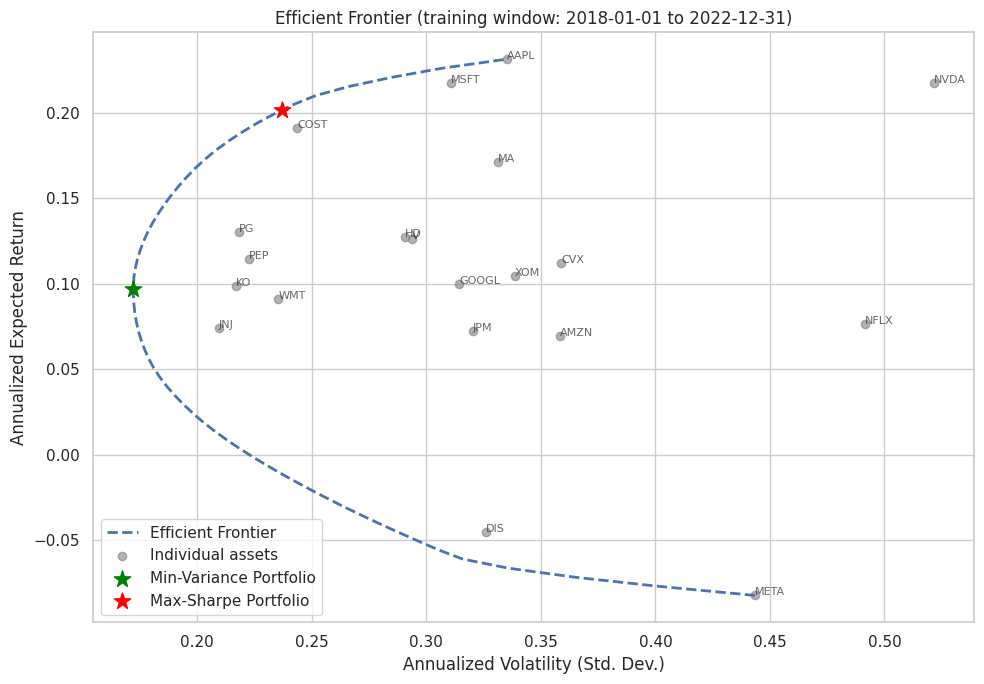

In [11]:
min_var_ret, min_var_vol = portfolio_performance(min_var_weights, mean_returns_annual.values, cov_matrix_annual.values)
max_sharpe_ret, max_sharpe_vol = portfolio_performance(max_sharpe_weights, mean_returns_annual.values, cov_matrix_annual.values)

# Individual assets, for reference
asset_vols = np.sqrt(np.diag(cov_matrix_annual.values))

plt.figure(figsize=(10, 7))
plt.plot(frontier_df["volatility"], frontier_df["return"], "b--", linewidth=2, label="Efficient Frontier")
plt.scatter(asset_vols, mean_returns_annual.values, c="gray", alpha=0.6, label="Individual assets")
for i, t in enumerate(asset_tickers):
    plt.annotate(t, (asset_vols[i], mean_returns_annual.values[i]), fontsize=8, alpha=0.7)

plt.scatter([min_var_vol], [min_var_ret], c="green", s=150, marker="*", label="Min-Variance Portfolio", zorder=5)
plt.scatter([max_sharpe_vol], [max_sharpe_ret], c="red", s=150, marker="*", label="Max-Sharpe Portfolio", zorder=5)

plt.xlabel("Annualized Volatility (Std. Dev.)")
plt.ylabel("Annualized Expected Return")
plt.title("Efficient Frontier (training window: {} to {})".format(TRAIN_START, TRAIN_END))
plt.legend()
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150)
plt.show()


## 9. Out-of-sample backtest

Apply the training-window weights to the **test window** actual prices —
the optimizer has not seen this data. Compare against buying and holding
the S&P 500 over the same period.

In [12]:
def backtest_weights(weights, price_data, tickers_subset):
    returns = price_data[tickers_subset].pct_change().dropna()
    portfolio_daily_returns = returns.dot(weights)
    cumulative = (1 + portfolio_daily_returns).cumprod()
    return portfolio_daily_returns, cumulative


min_var_daily, min_var_cum = backtest_weights(min_var_weights, prices_test, asset_tickers)
max_sharpe_daily, max_sharpe_cum = backtest_weights(max_sharpe_weights, prices_test, asset_tickers)

benchmark_daily = prices_test[benchmark].pct_change().dropna()
benchmark_cum = (1 + benchmark_daily).cumprod()

def annualized_stats(daily_returns, risk_free_rate=RISK_FREE_RATE):
    ann_return = (1 + daily_returns.mean()) ** 252 - 1
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    return ann_return, ann_vol, sharpe

for name, daily in [("Min-Variance", min_var_daily), ("Max-Sharpe", max_sharpe_daily), ("S&P 500", benchmark_daily)]:
    ret, vol, sharpe = annualized_stats(daily)
    print(f"{name:15s} | Ann. Return: {ret:6.2%} | Ann. Vol: {vol:6.2%} | Sharpe: {sharpe:5.2f}")


Min-Variance    | Ann. Return: 18.46% | Ann. Vol: 11.95% | Sharpe:  1.17
Max-Sharpe      | Ann. Return: 26.03% | Ann. Vol: 16.28% | Sharpe:  1.32
S&P 500         | Ann. Return: 21.88% | Ann. Vol: 14.76% | Sharpe:  1.18


## 10. Plot cumulative out-of-sample performance

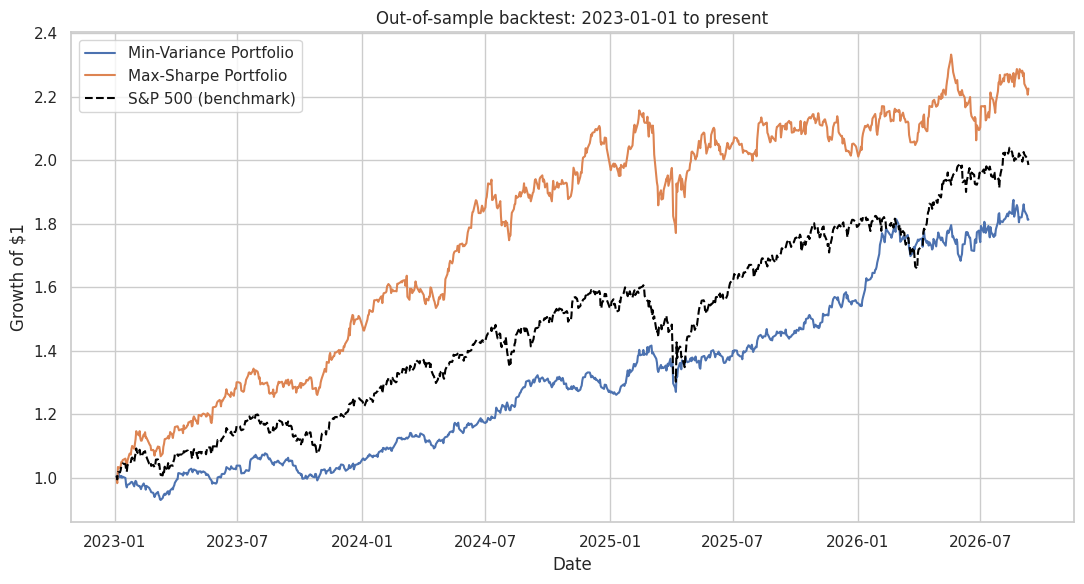

In [13]:
plt.figure(figsize=(11, 6))
plt.plot(min_var_cum.index, min_var_cum.values, label="Min-Variance Portfolio")
plt.plot(max_sharpe_cum.index, max_sharpe_cum.values, label="Max-Sharpe Portfolio")
plt.plot(benchmark_cum.index, benchmark_cum.values, label="S&P 500 (benchmark)", linestyle="--", color="black")

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title(f"Out-of-sample backtest: {TEST_START} to present")
plt.legend()
plt.tight_layout()
plt.savefig("backtest_performance.png", dpi=150)
plt.show()


## 11. Findings & limitations (fill in after running)

- **Headline result:** [Which portfolio had the best out-of-sample Sharpe
  ratio? Did either optimized portfolio actually beat the S&P 500, or did
  the benchmark win once fees/complexity are considered?]
- **Frontier shape:** [Was there a wide spread between min-variance and
  max-Sharpe portfolios, or did diversification benefits turn out to be
  modest for this particular 20-stock universe?]
- **Caveats to state explicitly:**
  - The "optimal" weights are optimal *with respect to the training
    window's realized statistics* — not a guarantee about the future.
    If out-of-sample performance disappoints, that is itself a legitimate
    and common finding in this literature, not a bug.
  - No rebalancing, transaction costs, taxes, or dividends reinvestment
    are modeled — report this as a simplification.
  - Survivorship bias: all 20 tickers are large, currently-listed firms.
  - No short-selling was allowed (weights ≥ 0) — note this constraint
    shapes the frontier and may hide diversification gains a long-short
    portfolio could capture.
